In [2]:
import sys
sys.path.append("../../src")
from common_imports import *
from equilibrium_critical_correlations import *

In [3]:
def P_l(n, l, even=True):
    """
    Same as P_n but each term has an additional spin appended at site -l.
    """
    indices = [i for i in range(0, n)]
    terms = kb.all_combinations(indices)

    x_c = []
    for a in terms[1:]:
        a = np.array(a)
        a = np.append(a, -l)  # append spin at -l
        a = np.sort(a)
        x_c.append(tuple(a - a[0]))
    counter = Counter(x_c)

    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices) % 2 == 1:
            if even:
                dat.append(0)
            else:
                constant = len(k) // 2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices))) * degen)
        else:
            dat.append(sigma_general(indices) * degen)
    dat.append(0)
    return np.sum(dat)/2**n

  0%|          | 0/11 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r

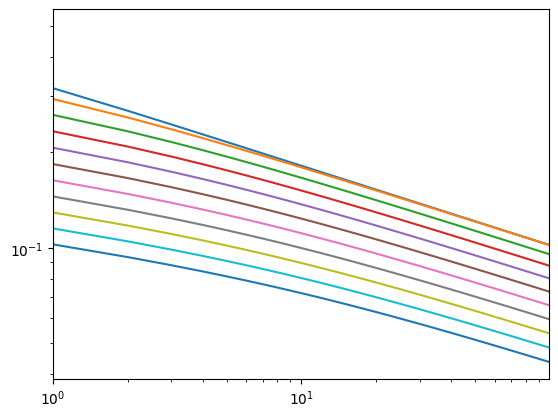

In [4]:
from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

r = np.arange(0, 100)
n_values = np.arange(1, 12)

def compute_for_n(n):
    return np.array(Parallel(n_jobs=-1)(
        delayed(P_l)(n, i) for i in r
    ))

results = np.array([compute_for_n(n) for n in tqdm(n_values)])  # shape (len(n_values), len(r))

for dat in results:
    plt.plot(r, dat)

plt.xlim(r[1], r[-1])
plt.loglog()
plt.show()

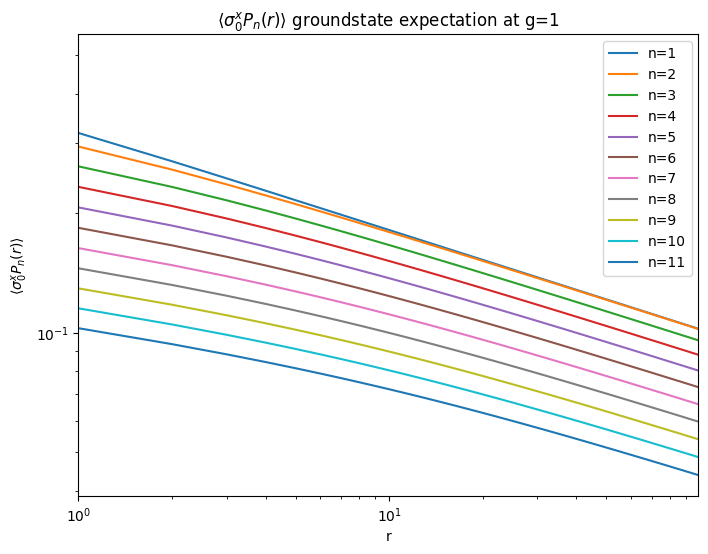

[]

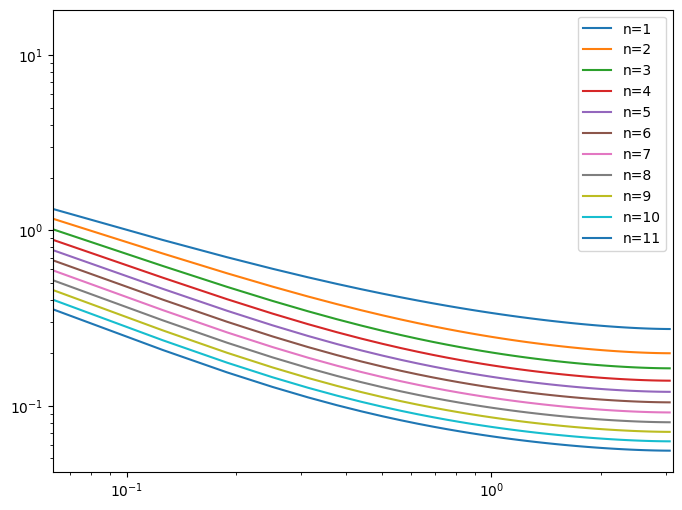

In [5]:
from numpy.fft import fft, fftfreq, fftshift
k = fftshift(fftfreq(len(r),1))*2*pi


plt.figure(figsize=(8,6))
sk = []
for i,res in enumerate(results):
    if i %1==0:
        n= i+1
        sk.append(fftshift(fft(res)))
        plot(r,res,label=f"n={i+1}")
    else:
        pass
loglog()
xlabel("r")
ylabel(r"$\langle \sigma_0^x P_n(r)\rangle$")
legend()
xlim(r[1],r[-1])
title(r"$\langle \sigma_0^x P_n(r)\rangle$ groundstate expectation at g=1")

show()
plt.figure(figsize=(8,6))

for i,s in enumerate(sk):
    plot(k,s,label=f"n={i+1}")

legend()
xlim(k[1]-k[0],pi)
loglog()

[(np.int64(0), np.int64(5)),
 (np.int64(0), np.int64(6)),
 (np.int64(0), np.int64(5), np.int64(6))]